In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import LinearOperator, eigsh
from torch.utils.data import DataLoader
from scripts.utils import create_synthetic_dataset, FlatMLP, train_model

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(SEED)

# ── Dataset & DataLoaders ──────────────────────────────────────────────────────
dataset = create_synthetic_dataset()
input_dim = dataset.tensors[0].shape[1]
criterion = torch.nn.CrossEntropyLoss()
full_dataloader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)

# ── Shared helper: Hessian-vector product ─────────────────────────────────────
def compute_hvp(model, dataset, v_np, device, batch_size=500):
    """Compute H·v without forming H, via autograd second-order differentials."""
    v_tensor = torch.tensor(v_np, dtype=torch.float32, device=device)
    hvp_accum = torch.zeros_like(v_tensor)
    crit = torch.nn.CrossEntropyLoss()
    for X_b, y_b in DataLoader(dataset, batch_size=batch_size, shuffle=False):
        X_b, y_b = X_b.to(device), y_b.to(device)
        model.zero_grad()
        loss = crit(model(X_b), y_b)
        grads = torch.autograd.grad(loss, model.parameters(), create_graph=True)
        flat_grad = torch.cat([g.contiguous().view(-1) for g in grads])
        grad_v = torch.dot(flat_grad, v_tensor)
        hvp_grads = torch.autograd.grad(grad_v, model.parameters())
        flat_hvp = torch.cat([g.contiguous().view(-1) for g in hvp_grads])
        hvp_accum += flat_hvp * len(X_b)
    return (hvp_accum / len(dataset)).detach().cpu().numpy()

# ── Shared helper: flatten / restore weights ──────────────────────────────────
def get_flat_weights(model):
    return torch.cat([p.data.contiguous().view(-1) for p in model.parameters()]).clone()

def set_flat_weights(model, flat_w):
    idx = 0
    for p in model.parameters():
        n = p.numel()
        p.data.copy_(flat_w[idx:idx + n].view_as(p.data))
        idx += n

# ── Shared helper: full-batch loss ────────────────────────────────────────────
def eval_loss(model, X, y, criterion):
    model.eval()
    with torch.no_grad():
        return criterion(model(X), y).item()

print("Setup complete.")


Setup complete.


In [ ]:
print("Training model to convergence (theta*)...")

trained_model = train_model(
    dataset=dataset,
    input_dim=input_dim,
    lr=0.005,
    batch_size=64,
    epochs=250,
    seed=SEED,
)
trained_model.eval()
device = next(trained_model.parameters()).device
X_all = dataset.tensors[0].to(device)
y_all = dataset.tensors[1].to(device)

with torch.no_grad():
    loss_baseline = criterion(trained_model(X_all), y_all).item()
theta_star = get_flat_weights(trained_model)

print(f"Equilibration complete!  L* = {loss_baseline:.5f}")


Training model to convergence (theta*)...
Epoch [100/250] | Loss: 0.0001 | Temp (lr/B): 0.00008
Epoch [200/250] | Loss: 0.0000 | Temp (lr/B): 0.00008
Equilibration complete!  L* = 0.00003


In [ ]:
K = 5  # Number of top eigenvectors to compute
print(f"Computing top-{K} Hessian eigenvectors via Lanczos (eigsh)...")

M = sum(p.numel() for p in trained_model.parameters())

def _hvp_op(v_np):
    return compute_hvp(trained_model, dataset, v_np, device, batch_size=500)

H_op = LinearOperator((M, M), matvec=_hvp_op)
evals_raw, evecs_raw = eigsh(H_op, k=K, which='LA')

sort_idx = np.argsort(evals_raw)[::-1]
evals = evals_raw[sort_idx].copy()
hessian_eigenvectors = evecs_raw[:, sort_idx].T.copy()  # shape (K, M)

lambda_1 = float(evals[0])
v_1      = hessian_eigenvectors[0]  # top eigenvector

print(f"Done.  λ₁ = {lambda_1:.4f}")
for i, lam in enumerate(evals):
    print(f"  λ_{i+1} = {lam:.4f}")

Computing top-5 Hessian eigenvectors via Lanczos (eigsh)...
Done.  λ₁ = 0.0086
  λ_1 = 0.0086
  λ_2 = 0.0077
  λ_3 = 0.0076
  λ_4 = 0.0074
  λ_5 = 0.0069


## Plot of true empirical loss vs the theoretical quadratic approximation ##

This plot has not eventually been inserted in the thesis

--- Verification of the Quadratic Local Approximation ---
Scanning loss landscape along the steepest Hessian eigenvector...


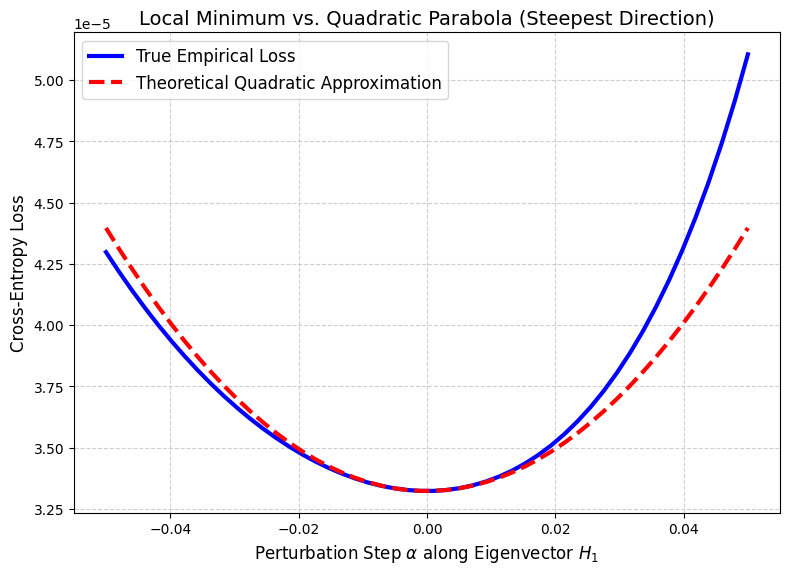

In [10]:
print("--- Verification of the Quadratic Local Approximation ---")

alphas = np.linspace(-0.05, 0.05, 50)
true_losses      = []
quadratic_losses = []

v1_t = torch.tensor(v_1, dtype=torch.float32, device=device)

print("Scanning loss landscape along the steepest Hessian eigenvector...")
for alpha in alphas:
    quadratic_losses.append(loss_baseline + 0.5 * lambda_1 * alpha ** 2)
    set_flat_weights(trained_model, theta_star + alpha * v1_t)
    true_losses.append(eval_loss(trained_model, X_all, y_all, criterion))

set_flat_weights(trained_model, theta_star)  # restore theta*

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(alphas, true_losses,      'b-',  linewidth=3, label="True Empirical Loss")
ax.plot(alphas, quadratic_losses, 'r--', linewidth=3, label="Theoretical Quadratic Approximation")
ax.set_title("Local Minimum vs. Quadratic Parabola (Steepest Direction)", fontsize=14)
ax.set_xlabel(r"Perturbation Step $\alpha$ along Eigenvector $H_1$", fontsize=12)
ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig("Quadratic_Approximation.png", dpi=300)
plt.show()

## Plot of the empirical true loss vs the theoretical quadratic approximation vs the fitted quadratic

--- Statistical Goodness-of-Fit Test for Quadratic Approximation ---

Fitted Quadratic:  0.005360·α²  +  0.000047·α  +  0.000033
Theoretical:       0.004292·α²  +  0.000000·α  +  0.000033

R²                        = 0.97385565  (1.0 = perfect quadratic fit)
Relative error on λ₁/2    = 24.8971%


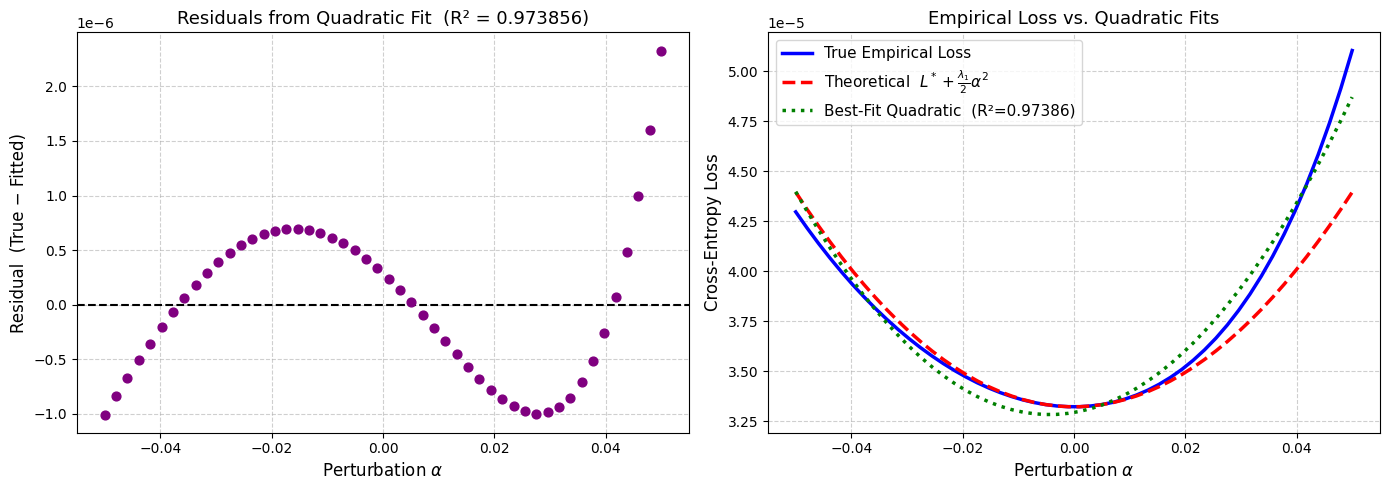

In [11]:
print("--- Statistical Goodness-of-Fit Test for Quadratic Approximation ---")

alphas_arr      = np.array(alphas)
true_losses_arr = np.array(true_losses)

# 1. Fit a degree-2 polynomial to the empirical data
coeffs = np.polyfit(alphas_arr, true_losses_arr, deg=2)
a_fit, b_fit, c_fit = coeffs
quad_fitted = np.polyval(coeffs, alphas_arr)

# 2. R² — how much variance is explained by a quadratic
ss_res    = np.sum((true_losses_arr - quad_fitted) ** 2)
ss_tot    = np.sum((true_losses_arr - np.mean(true_losses_arr)) ** 2)
r_squared = 1.0 - ss_res / ss_tot

# 3. Compare fitted curvature against theoretical prediction (lambda_1 / 2)
a_theory = lambda_1 / 2.0
b_theory = 0.0
c_theory = loss_baseline
rel_err  = abs(a_fit - a_theory) / abs(a_theory) * 100

print(f"\nFitted Quadratic:  {a_fit:.6f}·α²  +  {b_fit:.6f}·α  +  {c_fit:.6f}")
print(f"Theoretical:       {a_theory:.6f}·α²  +  {b_theory:.6f}·α  +  {c_theory:.6f}")
print(f"\nR²                        = {r_squared:.8f}  (1.0 = perfect quadratic fit)")
print(f"Relative error on λ₁/2    = {rel_err:.4f}%")

residuals = true_losses_arr - quad_fitted

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: residual plot
axes[0].scatter(alphas_arr, residuals, color='purple', s=40, zorder=5)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title(f"Residuals from Quadratic Fit  (R² = {r_squared:.6f})", fontsize=13)
axes[0].set_xlabel(r"Perturbation $\alpha$", fontsize=12)
axes[0].set_ylabel("Residual  (True − Fitted)", fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Right: three-way comparison
axes[1].plot(alphas_arr, true_losses_arr, 'b-', linewidth=2.5, label="True Empirical Loss")
axes[1].plot(alphas_arr, np.array(quadratic_losses), 'r--', linewidth=2.5,
             label=r"Theoretical  $L^* + \frac{\lambda_1}{2}\alpha^2$")
axes[1].plot(alphas_arr, quad_fitted, 'g:', linewidth=2.5,
             label=f"Best-Fit Quadratic  (R²={r_squared:.5f})")
axes[1].set_title("Empirical Loss vs. Quadratic Fits", fontsize=13)
axes[1].set_xlabel(r"Perturbation $\alpha$", fontsize=12)
axes[1].set_ylabel("Cross-Entropy Loss", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig("Quadratic_Fit_Test.png", dpi=300)
plt.show()

## Relative error of the theoretical quadratic vs the distance from the minimum

--- Quadratic Approximation: Width of Validity Region ---


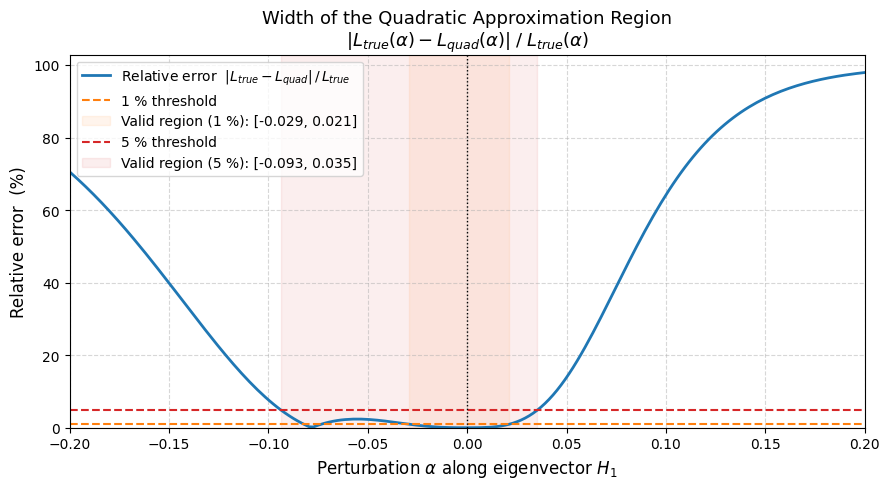

In [12]:
print("--- Quadratic Approximation: Width of Validity Region ---")

r_max      = 0.20
n_points   = 200
thresholds = [0.01, 0.05, 0.10]

alphas_wide      = np.linspace(-r_max, r_max, n_points)
true_losses_wide = []
quad_losses_wide = []

v1_t = torch.tensor(v_1, dtype=torch.float32, device=device)

with torch.no_grad():
    for alpha in alphas_wide:
        quad_losses_wide.append(loss_baseline + 0.5 * lambda_1 * alpha ** 2)
        set_flat_weights(trained_model, theta_star + alpha * v1_t)
        true_losses_wide.append(eval_loss(trained_model, X_all, y_all, criterion))

set_flat_weights(trained_model, theta_star)  # restore

true_losses_wide = np.array(true_losses_wide)
quad_losses_wide = np.array(quad_losses_wide)

abs_error = np.abs(true_losses_wide - quad_losses_wide)
with np.errstate(divide='ignore', invalid='ignore'):
    rel_error = np.where(true_losses_wide > 1e-12, abs_error / true_losses_wide, np.nan)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(alphas_wide, rel_error * 100, color='tab:blue', linewidth=2,
        label=r'Relative error  $|L_{true} - L_{quad}|\,/\,L_{true}$')

colors_thresh = ['tab:orange', 'tab:red']
for thr, col in zip(thresholds, colors_thresh):
    ax.axhline(thr * 100, color=col, linestyle='--', linewidth=1.5,
               label=f'{int(thr*100)} % threshold')
    mask = rel_error <= thr
    if mask.any():
        mid   = n_points // 2
        left  = mid
        right = mid
        while left  > 0             and mask[left  - 1]: left  -= 1
        while right < n_points - 1  and mask[right + 1]: right += 1
        ax.axvspan(alphas_wide[left], alphas_wide[right], alpha=0.08, color=col,
                   label=f'Valid region ({int(thr*100)} %): '
                         f'[{alphas_wide[left]:.3f}, {alphas_wide[right]:.3f}]')

ax.axvline(0, color='black', linestyle=':', linewidth=1)
ax.set_xlabel(r'Perturbation $\alpha$ along eigenvector $H_1$', fontsize=12)
ax.set_ylabel('Relative error  (%)', fontsize=12)
ax.set_title('Width of the Quadratic Approximation Region\n'
             r'$|L_{true}(\alpha) - L_{quad}(\alpha)|\;/\;L_{true}(\alpha)$',
             fontsize=13)
ax.set_xlim(-r_max, r_max)
ax.set_ylim(bottom=0)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("Quadratic_Validity_Region.png", dpi=300)
plt.show()